# Imports

In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate
from hapi import *
from pylab import plot
import pickle
from scipy.stats import chi2
from scipy.stats import norm


# from bin_spec import bin_spectrum
import seaborn as sns

os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/')
from bin_spec import bin_spectrum

%matplotlib widget

# Configuration

In [2]:
DATA_DIR = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data"
hapi_data_dir = "HAPI_DB"
atmospheric_profile_path = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data/external/atmosphere_profile.csv"

db_begin('/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB')
df_atmospheric_profile_table = pd.read_csv(atmospheric_profile_path)

Using /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB

CH4
                     Lines parsed: 2946
CH4_iso2
                     Lines parsed: 11300
H2O_iso3
                     Lines parsed: 763
N2_iso1
                     Lines parsed: 24
H2O_iso1
                     Lines parsed: 2120
CH4_iso1
                     Lines parsed: 21535
H2O_main
                     Lines parsed: 1123
CH4_iso3
                     Lines parsed: 962
N2O_iso1
                     Lines parsed: 16617
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 983


# User parameters

In [3]:
wl_min = 7.0
wl_max = 8.5
native_dwn = 0.0001     # cm^-1, native HITRAN-resolution sampling (HAPI side)

wn_min = 1e4/wl_max
wn_max = 1e4/wl_min


In [ ]:
#Global cache
# abs_coef_cache = {}

# Save absorption coefficient cache
# with open('abs_coef_cache_15kmclouds_7to8_5_range.pkl', 'wb') as f:
#     pickle.dump(abs_coef_cache, f)

# print("Cache saved successfully!")

# Open cache
with open('data/abs_coef_cache_15kmclouds_7to8_5_range.pkl', 'rb') as f:
    abs_coef_cache = pickle.load(f)

# print("Cache loaded!")

# Helper Functions

In [55]:
kB = 1.380649e-23  # Boltzmann constant, J/K

def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def compute_absorption_coefficient(molecule, isotope, dwn, altitude):
    """Compute absorption coefficient (cm^-1) for pure gas at layer conditions."""
    print(f"Computing coef for {molecule} iso{isotope} at alt {altitude}")
    M, __ = get_molecule_id(molecule)
    
    table_name = f"{molecule}_iso{isotope}"
    
    p_atm = df_atmospheric_profile_table["PRES_mb"].iloc[altitude] / 1013.25
    vmr = df_atmospheric_profile_table[f"{molecule}_ppmv"].iloc[altitude] / 1e6

    wn_grid, coef = absorptionCoefficient_Voigt(
        Components=[(M, isotope, vmr)],  # pure gas -> scale by vmr later
        Diluent={'self': vmr, 'air': 1.0 - vmr},
        SourceTables=table_name,
        WavenumberRange=(wn_min, wn_max),
        WavenumberStep=dwn,
        Environment={
            'T': df_atmospheric_profile_table["TEMP_K"].iloc[altitude], 
            'p': p_atm # Convert from mb to atmospheres
        },
        HITRAN_units=False  # Get absorption coefficient in cm^-1
    )
    return wn_grid, coef

def compute_reflectivity(molecules_isotopes, dwn, cloud_top = 8.0, albedo = 0.3): #cloud_top is in km
    '''
    Input: tuple list?: [(molecule, isotopes), ...], dwn, cloud_top (km), albedo

    computes intensity across wavelength for earth-like atmosphere

    Output: wavelengths_µm (array), transmission (array), wn_grid_ref (array)
    '''

    alt_df = df_atmospheric_profile_table.copy().reset_index(drop=True)
    
    # Layers above the cloud deck
    above_cloud_mask = alt_df["ALT_km"] >= cloud_top
    above_df = alt_df[above_cloud_mask].reset_index(drop=True)
    
    print(f"Computing reflectivity above cloud top at {cloud_top} km ({len(above_df)} layers)")
    
    alt_km = above_df["ALT_km"].values
    dz_km = np.diff(alt_km, append=alt_km[-1] + np.median(np.diff(alt_km)))
    dz_cm = dz_km * 1e5
    
    #temporary debug:
    # dz_cm *= 0.1
    total_tau = None
    wn_grid_ref = None
    
    for mol, iso in molecules_isotopes:
        col_name = f"{mol}_ppmv"   # <--- exact match to CSV
        print(f"Looking for column: {col_name}")
        if col_name not in alt_df.columns:
            print("ERROR: Column not found! Using available VMR-like columns:", [c for c in alt_df.columns if 'ppm' in c.lower() or 'vmr' in c.lower()])
            continue
            
        print(f"→ Processing {mol} iso{iso}")
        for i, row in above_df.iterrows():
            cache_key = (cloud_top, mol, iso, dwn, i)
            if cache_key in abs_coef_cache:
                wn_grid, coef_pure = abs_coef_cache[cache_key]
                print(f"  (cached) Layer {alt_km[i]:.1f} km")
            else:
                wn_grid, coef_pure = compute_absorption_coefficient(mol, iso, dwn, i)
                abs_coef_cache[cache_key] = (wn_grid, coef_pure)
                print(f"  Computed Layer {alt_km[i]:.1f} km")
            
            if wn_grid_ref is None:
                wn_grid_ref = wn_grid.copy()
            
            ppmv = float(row[col_name])
            vmr = ppmv * 1e-6

            # if mol == 'H2O':
            #     vmr *= 5e-4
            # if mol == 'N2O':
            #     vmr *= 8
            
            delta_tau = coef_pure * vmr * dz_cm[i]
            
            if total_tau is None:
                total_tau = np.zeros_like(coef_pure)
            total_tau += delta_tau
            
            # if i % 15 == 0:
            #     print(f"  Layer {alt_km[i]:5.1f} km | ppmv={ppmv:8.2f} | vmr={vmr:.2e} | max_delta_tau={np.max(delta_tau):.2e} | cum_max_tau={np.max(total_tau):.2e}")
    
    if total_tau is None:
        raise ValueError("No tau accumulated")
    
    total_tau_roundtrip = 2*total_tau
    
    print(f"\nFINAL: max_tau_roundtrip = {np.max(total_tau_roundtrip):.2f}, mean_tau = {np.mean(total_tau_roundtrip):.2f}")
    transmission_roundtrip = np.exp(-total_tau_roundtrip)
    print(f"Transmission range: {transmission_roundtrip.min():.6f} to {transmission_roundtrip.max():.6f}")

    reflectivity = albedo * transmission_roundtrip
    
    wavelengths_um = 1e4 / wn_grid_ref
    return wavelengths_um, transmission_roundtrip

def generate_res_dict(molecule_scenarios, resolutions, snrs=None, cloud_top=8.0, albedo=0.3):
    """
    molecule_scenarios: list of lists like [[('H2O', 1)], [('CO2', 1)], [('CH4',1), ('N2O',1)]]
    resolutions: list of R values (e.g. [100, 500, 1000])
    snrs: list of SNRs to inject noise for (e.g. [50, 100, 200]). If None, only clean spectra.
    """
    if snrs is None:
        snrs = []
    
    res_dict = {}
    
    for scenario in molecule_scenarios:
        # Create a nice scenario key (e.g. 'H2O', 'CH4+N2O')
        if len(scenario) == 1:
            scenario_key = scenario[0][0]
        else:
            scenario_key = '+'.join([mol for mol, iso in scenario])
        
        print(f"Computing high-res for scenario: {scenario_key}")
        
        # Compute once at very high resolution
        wl_high, refl_high = compute_reflectivity(
            scenario, 
            dwn=0.001, 
            cloud_top=cloud_top, 
            albedo=albedo
        )
        
        print(f"  High-res grid size: {len(wl_high)} points")
        
        for R in resolutions:
            res_key = int(R)
            
            if res_key not in res_dict:
                res_dict[res_key] = {}
            
            # Bin the clean spectrum
            wl_binned, refl_binned, _ = bin_spectrum(wl_high, refl_high, R)
            
            entry = {
                'wavelength_grid': wl_binned,
                'reflectivity_clean': refl_binned,
                'resolution': res_key,
            }
            
            # Add noisy versions for each SNR
            for snr in snrs:
                noisy, errors = inject_poisson_noise(refl_binned, snr=snr)
                entry[f'reflectivity_snr{snr}'] = noisy
                entry[f'error_snr{snr}'] = errors
            
            res_dict[res_key][scenario_key] = entry
    
    return res_dict

def inject_poisson_noise(trans, snr, seed=42, mode='gaussian_approx'):

    """
    Inject noise into a transmission or reflectivity spectrum.
    
    Parameters:
        signal: array of transmission or reflectivity (0 to 1)
        snr: desired signal-to-noise ratio (scalar or per-bin array)
        mode: 'gaussian_approx' (recommended) or 'true_poisson'
    """
    np.random.seed(seed)
    
    signal = 1 - trans

    if mode == 'gaussian_approx':
        # Most common approach for spectra
        noise_std = signal / snr          # relative noise
        noise = np.random.normal(0, noise_std)
        noisy = trans + noise
        errorbars = noise_std
        
    elif mode == 'true_poisson':
        # True Poisson if you have absolute photon counts
        # Assume max_signal corresponds to e.g. 1e6 photons
        max_counts = 1e9                   # SGL high photon count!!
        counts = signal * max_counts
        noisy_counts = np.random.poisson(counts)
        noisy = noisy_counts / max_counts 
        errorbars = np.sqrt(counts) / max_counts   # sqrt(N) / N0
    
    else:
        raise ValueError("mode must be 'gaussian_approx' or 'true_poisson'")
    
    # Clip to physical range
    noisy = np.clip(noisy, 0.0, 1.0)
    
    return noisy, errorbars

def cross_correlate_spectra(template_spectra, test_spectra, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation between two spectra.
    
    Returns a dictionary with all relevant results.
    """
    # Zero-mean normalization
    template_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
    test_norm     = (test_spectra     - np.mean(test_spectra))     / np.std(test_spectra)
    
    # Cross-correlation
    ccf = correlate(template_norm, test_norm, mode='full')
    ccf /= np.sqrt(np.sum(template_norm**2) * np.sum(test_norm**2))
    
    # Lags
    if lags is None:
        lags = np.arange(-len(template_norm) + 1, len(template_norm))
    
    # Basic statistics
    max_corr = np.max(ccf)
    peak_idx = np.argmax(ccf)
    
    # Noise estimation from wings (excluding central peak)
    window_size = int(0.15 * len(ccf))
    noise_mask = np.ones(len(ccf), dtype=bool)
    noise_mask[max(0, peak_idx - window_size): min(len(ccf), peak_idx + window_size)] = False
    noise_values = ccf[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
    
    # SNR array
    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)
    
    results = {
        'ccf': ccf,
        'lags': lags,
        'max_correlation': max_corr,
        'peak_lag': lags[peak_idx],
        'noise_std': noise_std,
        'template_norm': template_norm,
        'test_norm': test_norm,
    }
    
    if return_full:
        results['ccf_clean'] = np.clip(np.nan_to_num(ccf, nan=0.0), 0, None)
    
    return results

def compute_log_likelihood(template, test, noise_std=None):
    """
    Log-likelihood computation according to ana's paper
    """
    # Zero mean subtraction (used in paper)
    f = template - np.mean(template)
    g = test - np.mean(test)

    N = len(f)

    
    # amplitude scaling a (force to one)
    a = 1 #np.dot(f, g) / np.dot(g, g) if np.dot(g, g) > 0 else 1.0

    # Variances and cross-covariance
    s_f2 = 1/N * np.sum(f**2)
    s_g2 = 1/N * np.sum(g**2) #np.mean((a * g)**2)
    R = 1/N * np.sum(f * g) #np.mean(f * a * g)
    
    # residuals = f - a * g
    
    # noise_std = np.std(residuals)
    

    # Log-likelihood from equation (9)
    argument = s_f2 - 2 * R + s_g2
    if argument <= 0:
        argument = 1e-10  # prevent log of negative/zero
        print('argument less than = 0')
    
    logL = - (N / 2.0) * np.log(argument)
    
    return logL, a

    # logL = -N * np.log(noise_std) - 0.5 * np.sum((residuals / noise_std)**2)


def cross_correlate_two_templates(parent_dict, template_A, template_B, test_scenario):
    """
    Cross-correlate two specific clean templates against the noisy versions
    of a single test scenario.
    """
    records = []

    for r, res_data in parent_dict.items():
        # Check that everything we need exists
        if (template_A not in res_data or 
            template_B not in res_data or 
            test_scenario not in res_data):
            continue

        clean_key = 'reflectivity_clean'
        if clean_key not in res_data[template_A] or clean_key not in res_data[template_B]:
            continue

        template_A_spec = res_data[template_A][clean_key]
        template_B_spec = res_data[template_B][clean_key]

        # Loop over the noisy versions of the test scenario
        for key in res_data[test_scenario]:
            if not key.startswith('reflectivity_snr'):
                continue

            noisy_spec = res_data[test_scenario][key]
            snr_value = int(key.split('snr')[-1])

            if len(template_A_spec) != len(noisy_spec):
                continue

            # --- Template A ---
            results_A = cross_correlate_spectra(template_A_spec, noisy_spec)
            log_lik_A, _ = compute_log_likelihood(template_A_spec, noisy_spec, results_A['noise_std'])

            # --- Template B ---
            results_B = cross_correlate_spectra(template_B_spec, noisy_spec)
            log_lik_B, _ = compute_log_likelihood(template_B_spec, noisy_spec, results_B['noise_std'])

            delta_ll = log_lik_B - log_lik_A
            ts = 2* (delta_ll)
            p = chi2.sf(ts,df = 1)
            sigma = norm.isf(p/2.0)


            records.append({
                'resolution': r,
                'snr': snr_value,
                'template_A': template_A,
                'template_B': template_B,
                'test_scenario': test_scenario,
                'log_lik_A': log_lik_A,
                'log_lik_B': log_lik_B,
                'delta_logL': log_lik_B - log_lik_A,   # positive → B preferred
                'delta_logl_per_bin': (log_lik_B-log_lik_A)/len(template_A_spec),
                'max_corr_A': results_A['max_correlation'],
                'max_corr_B': results_B['max_correlation'],
                'ts': ts,
                'p': p,
                'sigma': sigma
            })

    df = pd.DataFrame(records)
    print(f"Generated {len(df)} records for {template_A} vs {template_B}")
    return df
    
def cross_correlate_spectra_in_dict(parent_dict, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation for all scenarios in input spectral dictionary
    
    Returns a dictionary with all relevant results.
    """

    records = []

    for r, res_data in parent_dict.items():
        for scen_template in res_data:
            clean_key = 'reflectivity_clean'
            if clean_key not in res_data[scen_template]:
                continue

            template_spectra = res_data[scen_template][clean_key]

            for scen_test in res_data:
                for key in list(res_data[scen_test].keys()):
                    if not key.startswith('reflectivity_snr'):
                        continue

                    noisy_spectra = res_data[scen_test][key]
                    snr_value = key.split('snr')[-1]

                    if len(template_spectra) != len(noisy_spectra):
                        continue

                    results = cross_correlate_spectra(template_spectra, noisy_spectra)

                    # Compute the log likelihood
                    log_lik, _ = compute_log_likelihood(template_spectra, noisy_spectra, results['noise_std'])

                    records.append({
                        'resolution': r,
                        'template_scenario': scen_template,
                        'test_scenario': scen_test,
                        'snr': int(snr_value),
                        'max_correlation': results['max_correlation'],
                        'peak_lag': results['peak_lag'],
                        'noise_std': results['noise_std'],
                        # 'ccf': results['ccf'],
                        # 'lags': results['lags'],
                        'log_lik': log_lik
                    })
    df = pd.DataFrame(records)
    print(f"Generated {len(df)} cross-correlation records")
    return df


# Test - Earth T-P Profile ✅

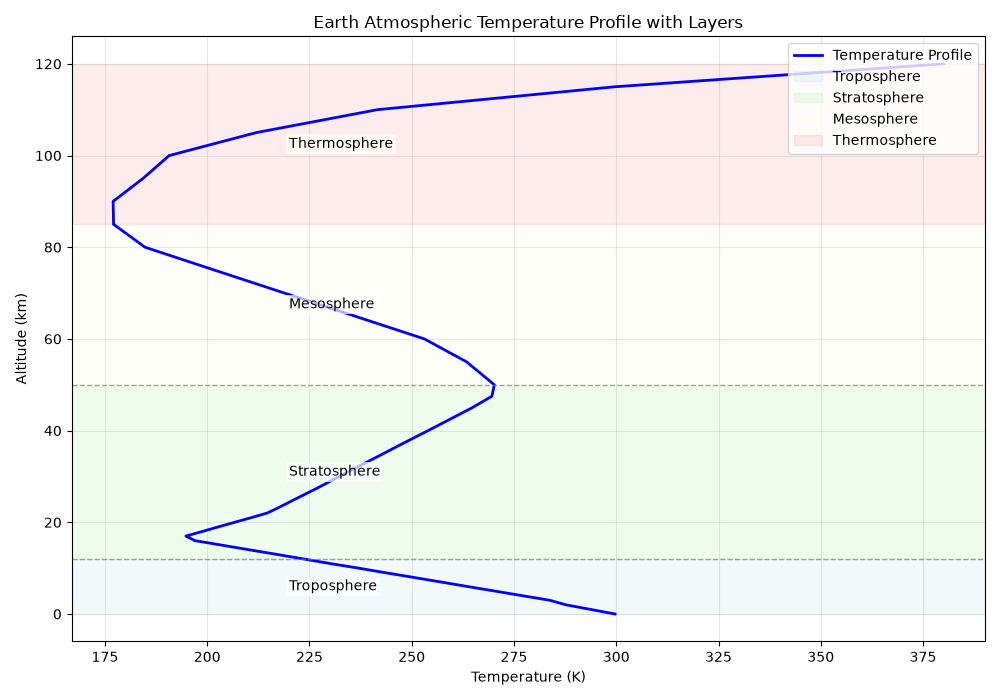

In [57]:
plt.figure(figsize=(10, 7))

# Main temperature profile
plt.plot(df_atmospheric_profile_table["TEMP_K"], 
         df_atmospheric_profile_table["ALT_km"], 
         color='blue', linewidth=2, label='Temperature Profile')

# Standard atmospheric layer boundaries (approximate)
layers = [
    (0, 12, "Troposphere", "lightblue"),
    (12, 50, "Stratosphere", "lightgreen"),
    (50, 85, "Mesosphere", "lightyellow"),
    (85, 120, "Thermosphere", "lightcoral")
]

for bottom, top, name, color in layers:
    plt.axhspan(bottom, top, alpha=0.15, color=color, label=name)
    # Label in the middle of the layer
    mid = (bottom + top) / 2
    plt.text(220, mid, name, fontsize=10, va='center', ha='left', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

plt.xlabel("Temperature (K)")
plt.ylabel("Altitude (km)")
plt.title("Earth Atmospheric Temperature Profile with Layers")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# Optional: mark tropopause etc.
plt.axhline(12, color='gray', linestyle='--', alpha=0.7, linewidth=1)
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, linewidth=1)

plt.tight_layout()
plt.show()

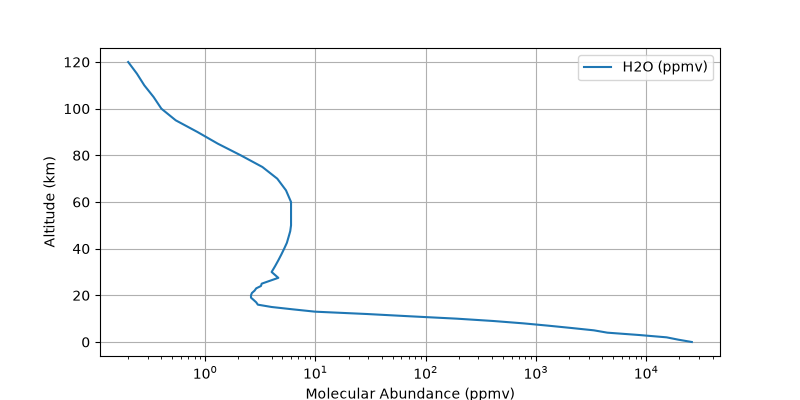

In [58]:
# Plotting molecular abundance profiles 

plt.figure(figsize=(8, 4))
plt.plot(df_atmospheric_profile_table["H2O_ppmv"], df_atmospheric_profile_table["ALT_km"], label="H2O (ppmv)")
# plt.plot( df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["CH4_ppmv"], label="CH4 (ppmv)")
# plt.plot(df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["O3_ppmv"], label="O3 (ppmv)")
# plt.plot(df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["N2O_ppmv"], label="N2O (ppmv)")
plt.xscale("log")
plt.xlabel("Molecular Abundance (ppmv)")
plt.ylabel("Altitude (km)")
plt.grid(True)
plt.legend()
plt.show()

# Test Reflectivity Spectra - ✅

In [ ]:
# Example
mols = [('H2O', 1)]  # adjust isotopes

# Downloading table with correct wn_min and wn_max:

# for mol, isotope in mols:
#     M, _ = get_molecule_id(mol)
#     table_name = f'{mol}_iso{isotope}'
#     fetch(table_name,M,isotope,wn_min,wn_max)

alts =  range(len(df_atmospheric_profile_table))  # or subset

wl, trans = compute_reflectivity(mols, dwn=0.01, cloud_top= 1)


Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O_iso1
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
Header written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.header
END DOWNLOAD
                     Lines parsed: 2120
PROCESSED
Computing reflectivity above cloud top at 1 km (49 layers)
Looking for column: H2O_ppmv
→ Processing H2O iso1
Computing 

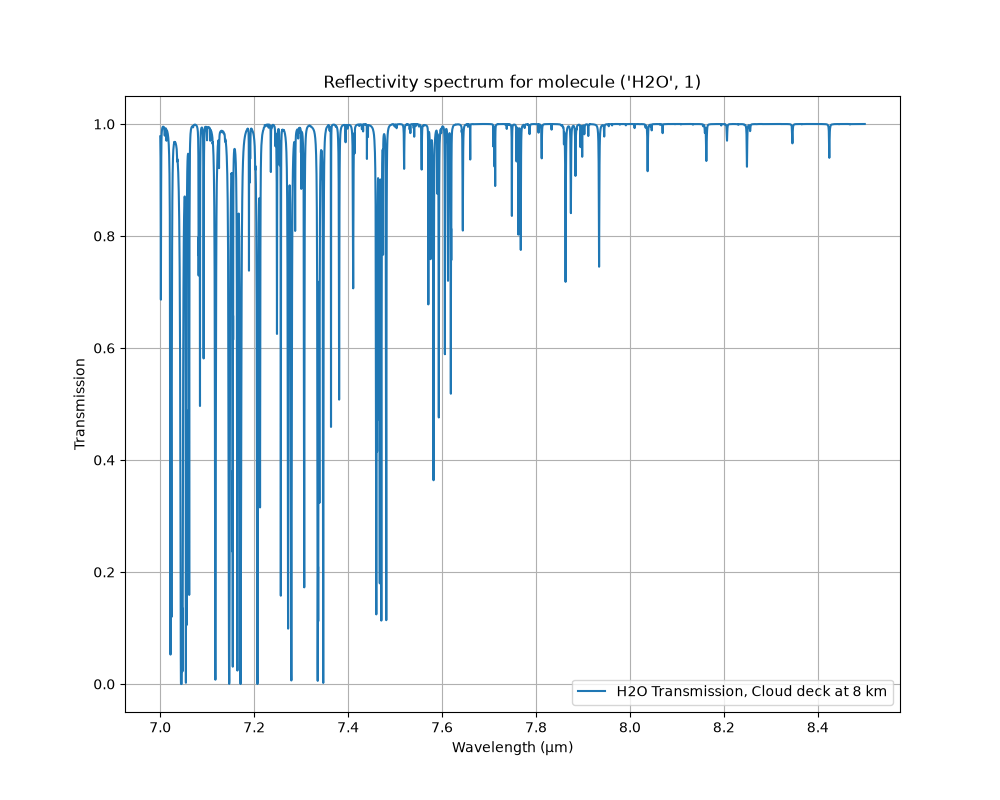

In [21]:
plt.figure(figsize=(10, 8))
plt.title(f"Reflectivity spectrum for molecule {mols[0]}")
plt.plot(wl, trans, label=f"{mols[0][0]} Transmission, Cloud deck at {8} km")
plt.xlabel("Wavelength (μm)")
plt.ylabel("Transmission")
# plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
snr = 10
noisy_trans, errors = inject_poisson_noise(trans, snr, mode='gaussian_approx')

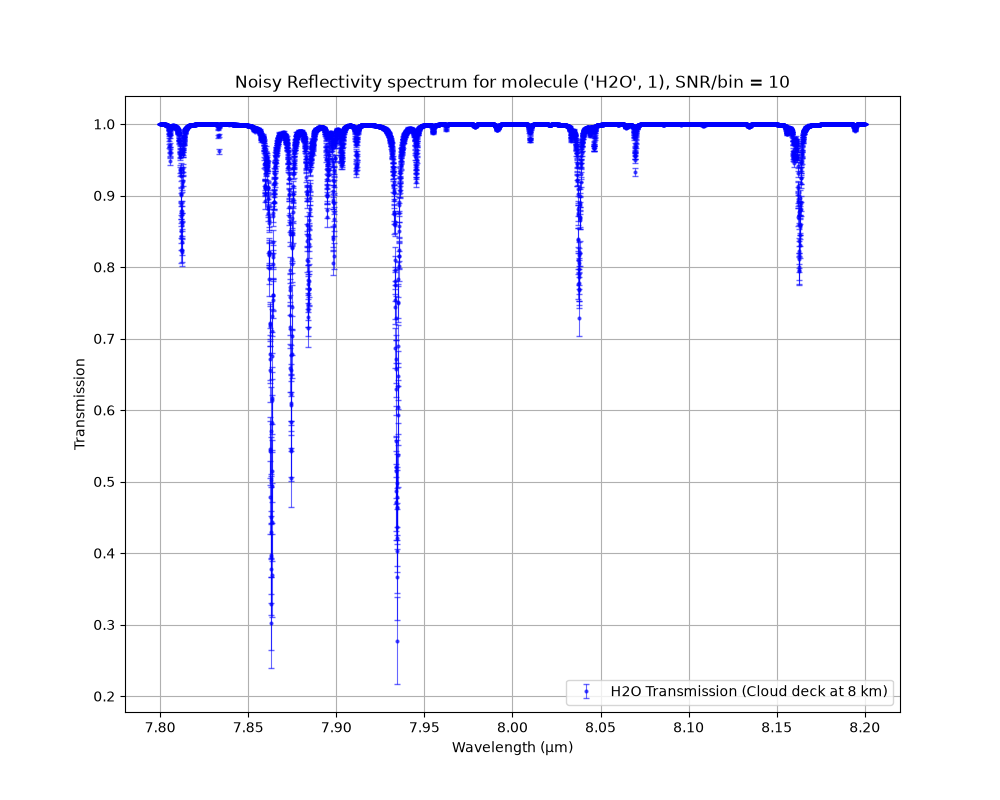

In [ ]:
plt.figure(figsize=(10, 8))
plt.title(f"Noisy Reflectivity spectrum for molecule {mols[0]}, SNR/bin = {snr}")
plt.errorbar(wl, noisy_trans, yerr=errors, fmt='o', markersize=2, 
             color='blue', ecolor='blue', elinewidth=0.8, capsize=2, 
             alpha=0.6, label=f"{mols[0][0]} Transmission (Cloud deck at 8 km)")
plt.xlabel("Wavelength (μm)")
plt.ylabel("Transmission")
# plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

# Dictionary generation

In [49]:
scenarios = [[('H2O', 1), ('CH4', 1), ('N2O', 1)], [('H2O', 1), ('CH4', 1)], [('CH4', 1), ('N2O', 1)]] #[('H2O', 1)], [('N2O', 1)], [('CH4', 1)], [('H2O', 1), ('N2O', 1)]


# recreating tables with correct wvenumber range
# mols = [('H2O', 1), ('CH4', 1), ('N2O', 1)]
# for mol, isotope in mols:
#     M, _ = get_molecule_id(mol)
#     table_name = f'{mol}_iso{isotope}'
#     fetch(table_name,M,isotope,wn_min,wn_max)
    

resolutions = [10000, 100000, 1e6, 1e7]
snrs = [3, 5, 10, 15, 20, 25, 50, 100, 200, 300]#, 1000]

res_dict = generate_res_dict(scenarios, resolutions, snrs, cloud_top=15.0, albedo=0.3)

Computing high-res for scenario: H2O+CH4+N2O
Computing reflectivity above cloud top at 15.0 km (35 layers)
Looking for column: H2O_ppmv
→ Processing H2O iso1
  (cached) Layer 15.0 km
  (cached) Layer 16.0 km
  (cached) Layer 17.0 km
  (cached) Layer 18.0 km
  (cached) Layer 19.0 km
  (cached) Layer 20.0 km
  (cached) Layer 21.0 km
  (cached) Layer 22.0 km
  (cached) Layer 23.0 km
  (cached) Layer 24.0 km
  (cached) Layer 25.0 km
  (cached) Layer 27.5 km
  (cached) Layer 30.0 km
  (cached) Layer 32.5 km
  (cached) Layer 35.0 km
  (cached) Layer 37.5 km
  (cached) Layer 40.0 km
  (cached) Layer 42.5 km
  (cached) Layer 45.0 km
  (cached) Layer 47.5 km
  (cached) Layer 50.0 km
  (cached) Layer 55.0 km
  (cached) Layer 60.0 km
  (cached) Layer 65.0 km
  (cached) Layer 70.0 km
  (cached) Layer 75.0 km
  (cached) Layer 80.0 km
  (cached) Layer 85.0 km
  (cached) Layer 90.0 km
  (cached) Layer 95.0 km
  (cached) Layer 100.0 km
  (cached) Layer 105.0 km
  (cached) Layer 110.0 km
  (cached) Lay

In [41]:
delta = np.mean(np.diff(data['wavelength_grid']))
wl_mean = np.mean(data['wavelength_grid'])

print('R = ', wl_mean/delta)

R =  9999993.515939564


In [43]:
# plt.close('all')
# plt.figure(figsize=(10,6))

# resolution_to_plot = 1e7
# scenario_to_plot = 'H2O+CH4+N2O'
# snr_to_plot_a = 50
# snr_to_plot_b = 100
# clean_plot = False

# data = res_dict[resolution_to_plot][scenario_to_plot]
# data_temp = res_dict[resolution_to_plot]['H2O+CH4']
# # data_temp2 = res_dict[resolution_to_plot]['N2O']

# plt.plot(data['wavelength_grid'], data[f'reflectivity_snr{snr_to_plot_b}'], label = f'{scenario_to_plot} Reflectivity at R = {resolution_to_plot}, SNR = {snr_to_plot_b}', alpha = 0.6)
# plt.plot(data['wavelength_grid'], data['reflectivity_clean'], label = f'H2O+CH4+N2O Reflectivity at R = {resolution_to_plot}', alpha = 0.6)
# plt.plot(data_temp['wavelength_grid'], data_temp[f'reflectivity_clean'], label = f'H2O+CH4 Reflectivity at R = {resolution_to_plot}', alpha = 0.6)


# # plt.plot(data_temp['wavelength_grid'], data_temp2['reflectivity_clean'], label = f'N2O Reflectivity at R = {resolution_to_plot}')


# plt.title('Reflectivity Spectra')
# plt.grid()
# # plt.legend()
# plt.show()

# Cross Correlation Tests

In [56]:
plt.close('all')
template_A = 'H2O+CH4'
template_B = 'H2O+CH4+N2O' 
test_scen = 'H2O+CH4+N2O'
df_cc = cross_correlate_two_templates(res_dict, template_A=template_A, template_B=template_B, test_scenario=test_scen)


# df_A = df_cc[(df_cc['template_scenario'] == template_A) & (df_cc['test_scenario'] == test_scen)].copy()
# df_B = df_cc[(df_cc['template_scenario'] == template_B) & (df_cc['test_scenario'] == test_scen)].copy()

# print("Rows A:", len(df_A), "Rows B:", len(df_B))

Generated 40 records for H2O+CH4 vs H2O+CH4+N2O


# Plotting Results

### Log-likelihood metric

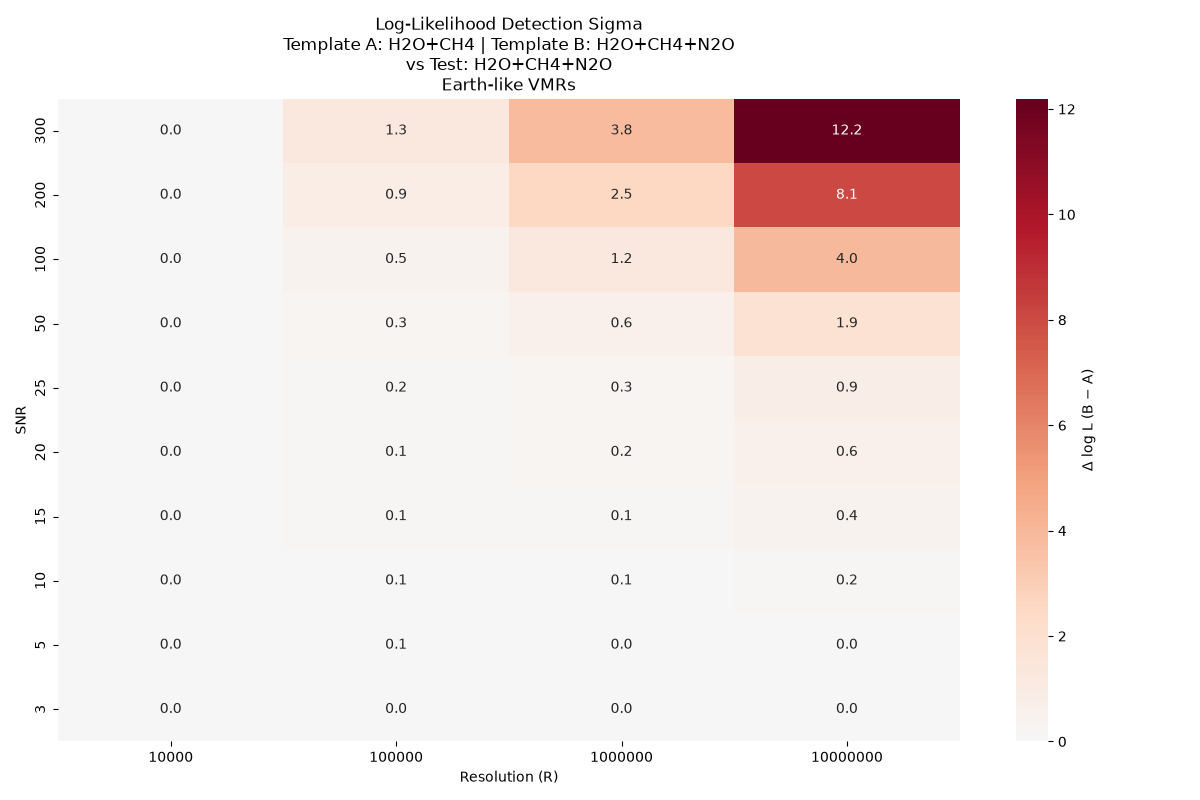

In [58]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# Use log-likelihood difference (A - B)
# merged['delta_logL'] = merged['log_lik_B'] - merged['log_lik_A']

# Optional: compute significance (how many sigma the difference is)
# merged['delta_significance'] = merged['delta_logL'] / np.sqrt(merged['noise_std_A']**2 + merged['noise_std_B']**2)

# ======================
# Pivot for heatmap
# ======================
pivot = df_cc.pivot_table(
    index='snr', 
    columns='resolution', 
    values='sigma',        # or 'delta_significance'
    aggfunc='mean'
).sort_index(ascending=False)   # SNR increasing upwards

# ======================
# Annotation
# ======================
annot = pivot.copy().astype(str)

for i, snr in enumerate(pivot.index):
    for j, res in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        annot.iloc[i, j] = f"{val:.1f}"

# ======================
# Plot
# ======================
plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot,
    cmap='RdBu_r',           
    center=0,
    annot=annot,
    fmt='', 
    cbar_kws={'label': 'Δ log L (B − A)'}
)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR')
plt.title(
    f'Log-Likelihood Detection Sigma\n'
    f'Template A: {template_A} | Template B: {template_B}\n'
    f'vs Test: {test_scen}\n'
    'Earth-like VMRs'
)

plt.tight_layout()
plt.show()

### Detection Significance

In [ ]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# merged['delta'] = merged['max_correlation_A'] - merged['max_correlation_B']
# merged['difference'] = merged['ccf_A'] - merged['ccf_B']   # array subtraction


# def compute_difference_stats(row):
#     diff = row['difference']
#     if not isinstance(diff, np.ndarray):
#         diff = np.array(diff)
    
#     peak_idx = (len(diff)-1)//2#np.argmax(np.abs(diff))
#     # print(len(diff))
#     # print(peak_idx)
#     peak_diff = diff[peak_idx]
    
#     length = len(diff)
#     window = int(0.15 * length)
#     noise_mask = np.ones(length, dtype=bool)
#     noise_mask[max(0, peak_idx - window): min(length, peak_idx + window)] = False
    
#     noise_values = diff[noise_mask]
#     noise_std = np.std(noise_values) if len(noise_values) > 10 else np.std(diff)

#     # noise_std = np.sqrt(row['noise_std_A']**2+row['noise_std_B']**2)
    
#     confidence = peak_diff / noise_std if noise_std > 0 else 0

#     # print(f'Standard deviation: {noise_std}, systemic difference: {peak_diff}')
    
#     return pd.Series({
#         'peak_difference': peak_diff,
#         'peak_lag': row['lags'][peak_idx] if 'lags' in row else peak_idx,
#         'noise_std': noise_std,
#         'difference_confidence': confidence
#     })

# stats = merged.apply(compute_difference_stats, axis=1)
# merged = pd.concat([merged, stats], axis=1)

In [ ]:
# plt.figure(figsize=(10,6))

# pivot = merged.pivot_table(index='snr', columns='resolution', values='difference_confidence').sort_index(ascending=False)

# sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu", center=0)
# plt.title(f"Correlation Significance\n (({template_A}) - ({template_B}) / std(diff)) vs Test spectra {test_scen}")

# plt.show()